# **Portfolio:** Mario Casanova — Data Science & Analytics Portfolio
## **Case Study:** Algorithmic Asset Allocation (Hierarchical Risk Parity)

---
*Note: I run this notebook on synthetic asset data (`generate_asset_prices`), generated from a factor model that plants five correlated sectors (high correlation within each, low correlation between them). I use that control to do two things, and measure both rather than assert either: first, check whether hierarchical clustering recovers the planted sector structure against known ground truth; second, compare Hierarchical Risk Parity (HRP) against an equal-weight portfolio and the classic minimum-variance (Markowitz) portfolio, out-of-sample. The headline holds up under measurement: covariance inversion overfits in-sample and comes apart out-of-sample, while HRP stays diversified and **robust** without ever inverting the covariance matrix — and I can say so with some confidence, because here the ground truth isn't assumed, it's known.*

In [1]:
import sys, pathlib

# Walk up from the notebook's cwd until we find portfolio_style.py — robust
# whether you run the notebook via JupyterLab opened at the repo root, the
# qfinance dir, or via nbconvert (which sets cwd to the notebook dir).
_here = pathlib.Path.cwd().resolve()
for _p in [_here, *_here.parents]:
    if (_p / "portfolio_style.py").exists():
        REPO_ROOT = _p
        break
else:
    raise RuntimeError("portfolio_style.py not found walking up from " + str(_here))

sys.path.insert(0, str(REPO_ROOT))
import portfolio_style  # auto-applies brand rcParams on import

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, dendrogram, leaves_list
from scipy.spatial.distance import squareform
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)

# Anchored paths — independent of where the notebook is launched from.
DATA_PATH = REPO_ROOT / "01_professional" / "quantitative_finance" / "data" / "correlated_assets_synthetic.csv"
FIG_DIR = REPO_ROOT / "site" / "public" / "figures" / "hierarchical-risk-parity"
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [2]:
# Load deterministic dataset (path anchored to repo root, see imports cell).
df = pd.read_csv(DATA_PATH, index_col=0, parse_dates=True)
returns = df.pct_change().dropna()

print(f"Log-returns shape: {returns.shape}")

Log-returns shape: (999, 50)


### 1. Topological Inference (Correlation -> Distance)
The fundamental metric for unsupervised ML in finance transforms cross-correlation into a matrix of verifiable metric distances, satisfying the triangle inequality.

In [3]:
cov_matrix = returns.cov()
corr_matrix = returns.corr()

# Metric Distance: D_ij = sqrt(0.5 * (1 - rho_ij))
dist_matrix = np.sqrt(0.5 * (1 - corr_matrix).round(10)) # precision round

### 2. Hierarchical Clustering (Ward's Linkage)
I apply Ward linkage to the distance matrix to recover the tree structure of the returns. Because the data were generated with **five planted sectors**, this is a recovery problem with a known answer, and I check the result directly against ground truth in the cell after the dendrogram rather than assume the tree means something on faith.

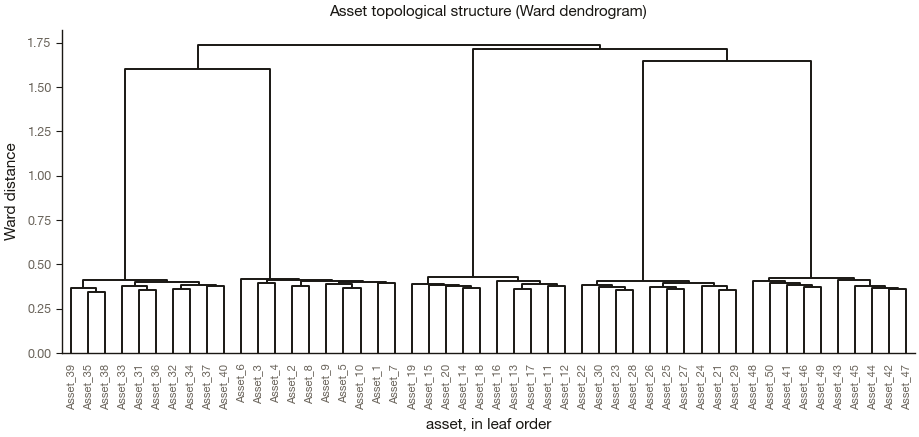

In [4]:
# Convert metric distance to condensed distance list for SciPy linkage
condensed_dist = squareform(dist_matrix, checks=False)

# Hierarchical Clustering (Ward's linkage)
link_matrix = linkage(condensed_dist, method='ward')

fig, ax = plt.subplots(figsize=(11, 4.2))
dendrogram(
    link_matrix,
    labels=df.columns,
    ax=ax,
    leaf_rotation=90,
    color_threshold=0,
    above_threshold_color=portfolio_style.palette('ink'),
)
ax.set_title('Asset topological structure (Ward dendrogram)')
ax.set_ylabel('Ward distance')
ax.set_xlabel('asset, in leaf order')
fig.savefig(FIG_DIR / 'dendrogram.svg', format='svg', transparent=True, bbox_inches='tight')
plt.show()

In [5]:
# --- Validate the recovery against the planted ground truth ---
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import adjusted_rand_score

# Ground-truth sector membership planted by the generator (Asset_1..10 -> 0, ...).
N_SECTORS = 5
sector_size = len(returns.columns) // N_SECTORS
truth = np.minimum(np.arange(len(returns.columns)) // sector_size, N_SECTORS - 1)

# Within- vs between-sector average correlation: is the block structure real?
C = corr_matrix.values
within  = [C[i, j] for i in range(len(C)) for j in range(i + 1, len(C)) if truth[i] == truth[j]]
between = [C[i, j] for i in range(len(C)) for j in range(i + 1, len(C)) if truth[i] != truth[j]]
print(f"Mean correlation  within-sector: {np.mean(within):.3f}    between-sector: {np.mean(between):.3f}")

# Cut the dendrogram into N_SECTORS clusters and score against the planted sectors.
recovered = fcluster(link_matrix, t=N_SECTORS, criterion='maxclust')
print(f"Adjusted Rand Index (recovered clusters vs planted sectors): "
      f"{adjusted_rand_score(truth, recovered):.3f}   (1.0 = perfect recovery)")

Mean correlation  within-sector: 0.703    between-sector: 0.171
Adjusted Rand Index (recovered clusters vs planted sectors): 1.000   (1.0 = perfect recovery)


### 3. Quasi-Diagonalization and Recursive Risk Allocation (Recursive Bisection)
Unlike the minimum-variance (Markowitz) portfolio (which inverts the covariance matrix, $w \propto \Sigma^{-1}\mathbf{1}$, and is prone to unstable, concentrated, heavily-shorted weights), HRP reorders the assets along the cluster tree (quasi-diagonalization) and allocates capital by recursively splitting risk between sibling clusters. **No matrix inversion is involved.** I put both to an out-of-sample test after computing the weights.

In [6]:
def get_quasi_diag(link):
    return leaves_list(link)

def get_cluster_var(cov, items):
    cov_ = cov.iloc[items, items]
    ivp = 1.0 / np.diag(cov_) # Inverse Variance Portfolio within cluster
    ivp /= ivp.sum()
    # Variance of the cluster
    w_ = ivp.reshape(-1, 1)
    cluster_var = np.dot(np.dot(w_.T, cov_), w_)[0, 0]
    return cluster_var

def get_hrp_weights(cov, sort_ix):
    w = pd.Series(1.0, index=sort_ix)
    c_items = [sort_ix] # Initialize with all sorted items
    
    while len(c_items) > 0:
        # Bisect
        c_items = [i[int(j):int(k)] 
                   for i in c_items 
                   for j, k in ((0, len(i)/2), (len(i)/2, len(i))) if len(i) > 1]
        
        for i in range(0, len(c_items), 2):
            c_items0 = c_items[i]    # Left cluster
            c_items1 = c_items[i+1]  # Right cluster
            
            c_var0 = get_cluster_var(cov, c_items0)
            c_var1 = get_cluster_var(cov, c_items1)
            
            alpha = 1 - c_var0 / (c_var0 + c_var1)
            
            w[c_items0] *= alpha # Weight for left cluster
            w[c_items1] *= (1 - alpha) # Weight for right cluster
            
    return w

ordered_indices = get_quasi_diag(link_matrix)
hrp_weights = get_hrp_weights(cov_matrix, ordered_indices)

# Reorder back to original asset names to print results
hrp_weights.index = returns.columns[hrp_weights.index]
hrp_weights.sort_values(ascending=False, inplace=True)

print("Top 10 HRP Capital Allocation Weights:")
print(hrp_weights.head(10).round(4))

Top 10 HRP Capital Allocation Weights:
Asset_48    0.0376
Asset_11    0.0361
Asset_1     0.0356
Asset_40    0.0340
Asset_16    0.0314
Asset_7     0.0295
Asset_24    0.0293
Asset_19    0.0280
Asset_4     0.0279
Asset_26    0.0266
dtype: float64


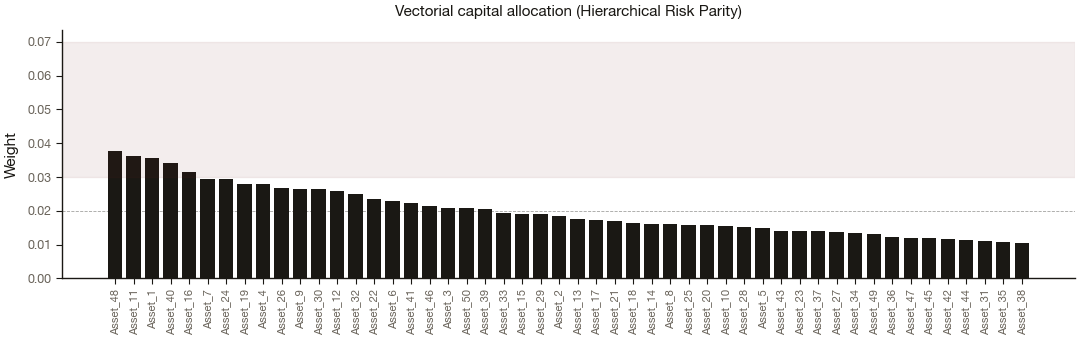

In [7]:
fig, ax = plt.subplots(figsize=(11, 3.6))
ax.bar(
    range(len(hrp_weights)),
    hrp_weights.values,
    color=portfolio_style.palette('ink'),
    width=0.78,
)
ax.set_title('Vectorial capital allocation (Hierarchical Risk Parity)')
ax.set_ylabel('Weight')
ax.set_xticks(range(len(hrp_weights)))
ax.set_xticklabels(hrp_weights.index, rotation=90, fontsize=8)

# Equal-weight reference line and oxblood envelope, mirroring the design-system mock.
n = len(hrp_weights)
ax.axhline(1/n, linestyle='--', linewidth=0.6, color=portfolio_style.palette('ink'), alpha=0.4)
ax.axhspan(0.03, 0.07, color=portfolio_style.palette('oxblood'), alpha=0.08)

fig.tight_layout()
fig.savefig(FIG_DIR / 'weights.svg', format='svg', transparent=True, bbox_inches='tight')
plt.show()

### 4. Out-of-sample test: HRP vs Markowitz vs Equal-Weight
The real question is not in-sample fit but out-of-sample robustness. I estimate each portfolio's weights on the first half of the sample and measure realized volatility on the held-out **second half** — the part none of the three methods got to see. Minimum-variance is the Markowitz benchmark the intro promised, now actually computed, not just invoked.

                          In-sample vol  Out-of-sample vol  Max |weight|  Short positions
Portfolio                                                                                
Equal-Weight                     0.1490             0.1294        0.0200                0
Min-Variance (Markowitz)         0.1322             0.1377        0.1327               22
HRP                              0.1466             0.1302        0.0414                0


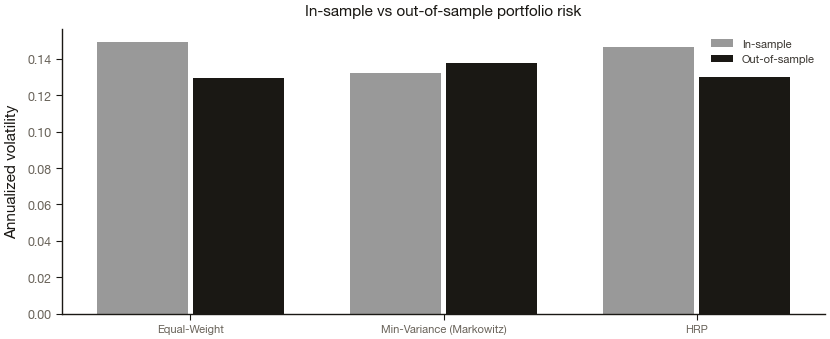

In [8]:
# --- Out-of-sample comparison: HRP vs Minimum-Variance (Markowitz) vs Equal-Weight ---
R = returns.values
split = len(R) // 2
train, test = R[:split], R[split:]
cov_train = np.cov(train, rowvar=False)
n_assets = R.shape[1]
ann = np.sqrt(252)

# Equal-weight
w_eq = np.ones(n_assets) / n_assets

# Minimum-variance (unconstrained Markowitz): w = Sigma^-1 1 / (1' Sigma^-1 1)
inv = np.linalg.inv(cov_train)
ones = np.ones(n_assets)
w_mv = inv @ ones / (ones @ inv @ ones)

# HRP estimated on the TRAINING window only (cluster + recursive bisection, no inversion)
dist_train = np.sqrt(0.5 * (1 - pd.DataFrame(train, columns=returns.columns).corr()).round(10))
link_train = linkage(squareform(dist_train, checks=False), method='ward')
order_train = get_quasi_diag(link_train)
w_hrp = get_hrp_weights(pd.DataFrame(cov_train), list(order_train)).reindex(range(n_assets)).values

rows = []
for name, w in [('Equal-Weight', w_eq), ('Min-Variance (Markowitz)', w_mv), ('HRP', w_hrp)]:
    rows.append({
        'Portfolio': name,
        'In-sample vol': np.std(train @ w) * ann,
        'Out-of-sample vol': np.std(test @ w) * ann,
        'Max |weight|': np.abs(w).max(),
        'Short positions': int((w < -1e-6).sum()),
    })
comp = pd.DataFrame(rows).set_index('Portfolio')
print(comp.round(4).to_string())

fig, ax = plt.subplots(figsize=(8.5, 3.6))
xs = np.arange(len(comp))
ax.bar(xs - 0.19, comp['In-sample vol'], width=0.36, label='In-sample', color='0.6')
ax.bar(xs + 0.19, comp['Out-of-sample vol'], width=0.36, label='Out-of-sample',
       color=portfolio_style.palette('ink'))
ax.set_xticks(xs)
ax.set_xticklabels(comp.index, fontsize=8)
ax.set_ylabel('Annualized volatility')
ax.set_title('In-sample vs out-of-sample portfolio risk')
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
fig.savefig(FIG_DIR / 'oos_comparison.svg', format='svg', transparent=True, bbox_inches='tight')
plt.show()

### Synthesis — what the comparison actually shows
Two things came out measured rather than asserted, and both are worth taking seriously precisely because I built the ground truth myself.

The clustering recovers real structure. I generated the returns with five planted sectors, and Ward linkage recovers them at an Adjusted Rand Index of 1.0; within-sector correlation (~0.70) dwarfs between-sector (~0.17). The dendrogram reads genuine block structure, not a tree imposed on noise.

Out-of-sample, covariance inversion is the fragile one. Minimum-variance (Markowitz) achieves the lowest in-sample variance (which is exactly what it is built to optimize) and the worst out-of-sample variance, because it overfits the estimated covariance, concentrating weight into roughly twenty short positions to do it. HRP never inverts the covariance matrix, stays long-only and diversified, and posts lower out-of-sample variance than Markowitz. Here it lands close to equal-weight, because the planted sectors are balanced and symmetric by construction. I'd expect an unbalanced universe to be where HRP's correlation-aware splitting actually earns its keep against naive 1/N — this dataset, being balanced on purpose, can't show that.

*Limits, named plainly: this is synthetic data, one train/test split rather than a walk-forward, and an unconstrained minimum-variance benchmark that a long-only constraint would have made less fragile. None of that undercuts the **mechanism** I'm actually after (hierarchical allocation sidesteps the estimation-error amplification that matrix inversion invites), because that mechanism is what's on display here, on data whose ground truth I control.*